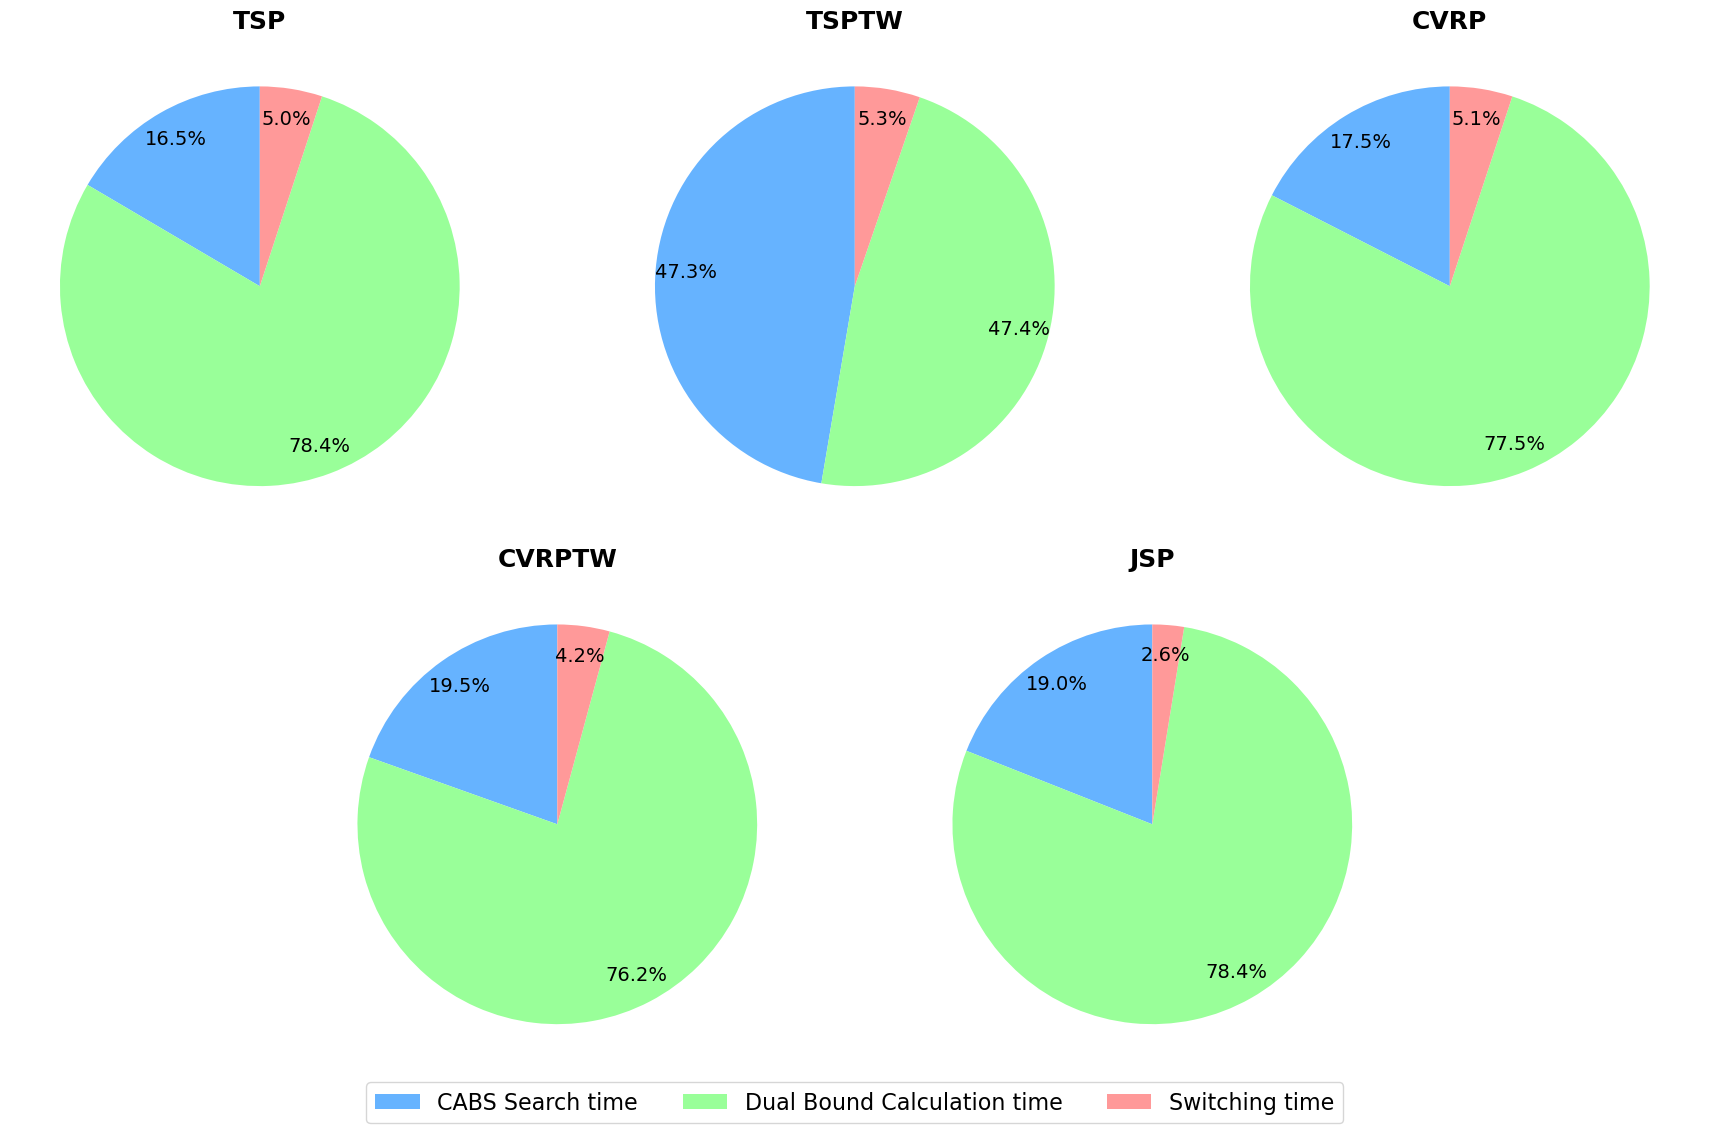

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- CONFIGURATION: Input Files ---
files = {
    'TSP_20': 'TSP_EA_dual_bound_verification_results_20_cus_1800s_lim.csv',
    'TSP_50': 'TSP_EA_dual_bound_verification_results_50_cus_1800s_lim.csv',
    'TSPTW_20': 'TSPTW_EA_dual_bound_verification_results_20_cus_1800s_lim.csv',
    'TSPTW_50': 'TSPTW_EA_dual_bound_verification_results_50_cus_1800s_lim.csv',
    'CVRP': 'Backup_v1_CVRP_EA_dual_bound_verification_results_1800s_lim.csv',
    'CVRPTW': 'CVRPTW_EA_dual_bound_verification_results_1800s_lim.csv',
    'JSP': 'Backup_v2_JSP_EA_dual_bound_verification_results_1800s_lim.csv'
}

# Domains Organization
domains_top = ['TSP', 'TSPTW', 'CVRP']
domains_bottom = ['CVRPTW', 'JSP']

domain_files = {
    'TSP': ['TSP_20', 'TSP_50'],
    'TSPTW': ['TSPTW_20', 'TSPTW_50'],
    'CVRP': ['CVRP'],
    'CVRPTW': ['CVRPTW'],
    'JSP': ['JSP']
}

domain_stats = {}

# --- PROCESS DATA ---
for domain, file_keys in domain_files.items():
    dfs = []
    for key in file_keys:
        dfs.append(pd.read_csv(files[key]))
    
    combined_df = pd.concat(dfs, ignore_index=True)
    
    # Calculate Times
    avg_total = combined_df['Total Times (s)'].mean()
    avg_bridging = combined_df['Bridging Time (s)'].mean()
    avg_dual = combined_df['Python Bound Time (s)'].mean()
    
    # Logic:
    # Total = CABS + Bridging
    # Bridging = Switching + Dual Calc
    avg_cabs = max(0, avg_total - avg_bridging)
    avg_switching = max(0, avg_bridging - avg_dual)
    avg_dual_calc = avg_dual
    
    domain_stats[domain] = {
        'CABS Search Time': avg_cabs,
        'Dual Bound Calculation Time': avg_dual_calc,
        'Switching Time': avg_switching
    }

# --- PLOTTING ---
fig = plt.figure(figsize=(18, 12))
# Use GridSpec to center the bottom row
# 2 Rows, 6 Columns allows perfect centering for 3 items (2 cols each) and 2 items (3 cols each or centered 2 cols)
gs = gridspec.GridSpec(2, 6)

colors = ['#66b3ff', '#99ff99', '#ff9999']
labels = ['CABS Search time', 'Dual Bound Calculation time', 'Switching time']
text_props = {'fontsize': 14} # Bigger percentage text

# --- TOP ROW (TSP, TSPTW, CVRP) ---
# Each takes 2 columns [0:2], [2:4], [4:6]
top_axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6])
]

for i, domain in enumerate(domains_top):
    ax = top_axes[i]
    stats = domain_stats[domain]
    sizes = [stats['CABS Search Time'], stats['Dual Bound Calculation Time'], stats['Switching Time']]
    ax.pie(sizes, labels=None, autopct='%1.1f%%', startangle=90, colors=colors, textprops=text_props, pctdistance=0.85)
    ax.set_title(domain, fontsize=18, fontweight='bold')

# --- BOTTOM ROW (CVRPTW, JSP) ---
# To center 2 items in a 6-column grid, we place them at [1:3] and [3:5], leaving 0 and 5 empty
bottom_axes = [
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5])
]

for i, domain in enumerate(domains_bottom):
    ax = bottom_axes[i]
    stats = domain_stats[domain]
    sizes = [stats['CABS Search Time'], stats['Dual Bound Calculation Time'], stats['Switching Time']]
    ax.pie(sizes, labels=None, autopct='%1.1f%%', startangle=90, colors=colors, textprops=text_props, pctdistance=0.85)
    ax.set_title(domain, fontsize=18, fontweight='bold')

# --- LEGEND ---
fig.legend(labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.05), fontsize=16)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1) # Add space at bottom for legend
plt.savefig('domain_time_breakdown_pie_2rows.png', bbox_inches='tight')
plt.show()